# 1. Wprowadzenie
- **Autor:** Karolina Stefańska s227822
- **Temat projektu:** Analiza i identyfikacja kluczowych czynników wpływających na wartość
nieruchomości w celu predykcji przyszłej wartości (ceny za noc) obiektu w regionie Azji i Pacyfiku
dostępnego do wynajmu na platformie Airbnb.
- **Cel projektu:** Głównym celem projektu jest stworzenie modelu uczenia maszynowego (regresji),
który pozwoli na przewidywanie przychodu z wynajmu Airbnb w regionie Azji i Pacyfiku. Projekt ma
na celu pomoc w podejmowaniu decyzji inwestycyjnych dla przyszłych hostów (właścicieli
apartamentów na platformie Airbnb). <br>
Projekt zakłada wykorzystanie zmiennych subiektywnych (oceny, liczba opinii) jako dodatkowych
parametrów, pozwalających na długoterminową analizę. Dzięki temu użytkownik (inwestor) będzie
mógł oszacować zarówno bazową cenę nowej oferty, jak i potencjalny wzrost przychodów po
uzyskaniu statusu Superhosta lub wysokich ocen. Dzięki temu model mógłby być również przydatny
dla obecnych właścicieli, by zweryfikować i zoptymalizować cenę za noc ich nieruchomości.

# 2. Zbiór danych
- **Źródło:** https://www.kaggle.com/datasets/jasonairroi/airbnb-market-data-asia-pacific
- **Liczba obserwacji:** 29,440
- **Liczba zmiennych:** 61, w tym finalnie 12, które zostaną wzięte pod uwagę w modelu. Ostatnie 2 zmienne z tabeli to tworzą zmienną objaśnianą
- **Cecha do przewidzenia przez model:** przychód w USD

In [1303]:
import pandas as pd
import numpy as np
zmienne= pd.DataFrame([
    ('guests','maksymakna liczba gości', 'skokowa'),
    ('bedrooms', 'liczba sypialni', 'skokowa'),
    ('beds' ,'liczba łóżek', 'skokowa'),
    ('room_type','standard prywatności','kategoryczna (3)'),
    ('listing_type', 'standard akomodacji', 'kategoryczna') ,
    ('latitude', 'szerokość geograficza', 'ciągła'),
    ('longitude', 'długość geograficzna' ,'ciągła'),
    ('city', 'miasto', 'kategoryczna'),
    ('superhost', 'status superhosta', 'binarna'),
    ('num_reviews', 'lb. opinii', 'skokowa'),
    ('rating_overall', 'średnie opinie', 'ciągła'),
    ('photos_count', 'liczba zdjęć', 'skokowa'),
    ('instant_book', 'możliwość natychmiastowej rezerwacji', 'binarna'),
    ('l90d_revenue', 'przychód w USD', 'ciągła'),
    ], columns=('nazwa zmiennej', 'opis zmiennej', 'typ zmiennej'))
zmienne


,nazwa zmiennej,opis zmiennej,typ zmiennej
0,guests,maksymakna liczba gości,skokowa
1,bedrooms,liczba sypialni,skokowa
2,beds,liczba łóżek,skokowa
3,room_type,standard prywatności,kategoryczna (3)
4,listing_type,standard akomodacji,kategoryczna
5,latitude,szerokość geograficza,ciągła
6,longitude,długość geograficzna,ciągła
7,city,miasto,kategoryczna
8,superhost,status superhosta,binarna
9,num_reviews,lb. opinii,skokowa


## Wczytywanie danych i opis danych
oczyszczam dane z " na początku i końcu linii i zamieniam podwójne cudzysłowy z kolumny o udogodnieniach. Nastpęnie wczytuję dane z pliku csv pomijając wersy z błędami (wersy te nie mają listing_id)

In [1304]:
with open('listings.csv', 'r', encoding='utf-8') as file:
    clean_lines=[line.strip('"').replace('""', '"') for line in file]

with open('listings_cleaned.csv', 'w', encoding='utf-8') as file_out:
    for line in clean_lines:
        file_out.write(line)

del clean_lines
# import os
# os.remove('listings.csv')

In [1305]:
pd.set_option('display.max_columns', None)
listings_all_data = pd.read_csv(
    'listings_cleaned.csv', 
    quotechar='"', 
    doublequote=True, 
    skipinitialspace=True,
    on_bad_lines='skip'
)
listings_all_data.head(8)
listings_all_data.columns


C:\Users\karol\AppData\Local\Temp\ipykernel_10380\3960223325.py:2: DtypeWarning: Columns (0: photos_count, 1: latitude, 2: guests, 3: bedrooms, 4: num_reviews, 5: l90d_available_days, 6: l90d_total_days) have mixed types. Specify dtype option on import or set low_memory=False.
  listings_all_data = pd.read_csv(


Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'latitude', 'longitude',
       'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee',
       'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'ttm_total_days', 'l90d_revenue',
       'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
       'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
 

tworzę ramkę danych tylko z kolumn, które mnie interesują

In [1306]:
nazwy_zmiennych=list(zmienne.loc[:,'nazwa zmiennej'])
listings_df=listings_all_data.loc[:,nazwy_zmiennych]
listings_df.head(5)

,guests,bedrooms,beds,room_type,listing_type,latitude,longitude,city,superhost,num_reviews,rating_overall,photos_count,instant_book,l90d_revenue
0,14,7,10.0,entire_home,Entire villa,-8.6867,115.1564,"Seminyak""",false,73.0,4.52,43.0,NaN,11007.0
1,6,3,3.0,entire_home,Entire villa,-8.6958,115.1725,"Seminyak""",true,152.0,4.72,21.0,NaN,5759.0
2,10,4,4.0,entire_home,Entire villa,-8.6927,115.1657,"Seminyak""",true,118.0,4.71,18.0,NaN,5110.0
3,8,4,5.0,entire_home,Entire villa,-8.6905,115.1640,"Seminyak""",true,127.0,4.91,80.0,NaN,22294.0
4,14,7,8.0,entire_home,Entire villa,-8.6908,115.1632,"Seminyak""",true,6.0,4.80,63.0,NaN,16164.0


In [1307]:
listings_df['city'] = listings_df['city'].map(lambda x: str(x).strip('"'))
listings_df.head(3)

,guests,bedrooms,beds,room_type,listing_type,latitude,longitude,city,superhost,num_reviews,rating_overall,photos_count,instant_book,l90d_revenue
0,14,7,10.0,entire_home,Entire villa,-8.6867,115.1564,Seminyak,false,73.0,4.52,43.0,NaN,11007.0
1,6,3,3.0,entire_home,Entire villa,-8.6958,115.1725,Seminyak,true,152.0,4.72,21.0,NaN,5759.0
2,10,4,4.0,entire_home,Entire villa,-8.6927,115.1657,Seminyak,true,118.0,4.71,18.0,NaN,5110.0


In [1308]:
listings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29169 entries, 0 to 29168
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   guests          24614 non-null  object 
 1   bedrooms        22476 non-null  object 
 2   beds            28292 non-null  float64
 3   room_type       28787 non-null  str    
 4   listing_type    28787 non-null  str    
 5   latitude        28786 non-null  object 
 6   longitude       28786 non-null  float64
 7   city            29169 non-null  str    
 8   superhost       28785 non-null  str    
 9   num_reviews     28748 non-null  object 
 10  rating_overall  27832 non-null  float64
 11  photos_count    28497 non-null  object 
 12  instant_book    3412 non-null   str    
 13  l90d_revenue    28779 non-null  float64
dtypes: float64(4), object(5), str(5)
memory usage: 3.1+ MB


In [1309]:
listings_df['guests'] = pd.to_numeric(listings_df['guests'], errors='coerce')
listings_df['bedrooms'] = pd.to_numeric(listings_df['bedrooms'], errors='coerce')
listings_df['latitude'] = pd.to_numeric(listings_df['latitude'], errors='coerce')
listings_df['num_reviews'] = pd.to_numeric(listings_df['num_reviews'], errors='coerce')
listings_df['photos_count'] = pd.to_numeric(listings_df['photos_count'], errors='coerce')
listings_df['superhost'] = listings_df['superhost'].map(lambda x: False if x=='False' else True)

In [1310]:
listings_df.describe()

,guests,bedrooms,beds,latitude,longitude,num_reviews,rating_overall,photos_count,l90d_revenue
count,24613.000000,22475.000000,28292.000000,28785.000000,28786.000000,28747.000000,27832.000000,2.849600e+04,2.877900e+04
mean,4.796774,2.060156,2.646861,5.603658,119.627171,121.817380,4.761141,7.439223e+04,3.282858e+03
std,3.272582,1.544837,2.356941,22.970648,23.574772,325.902086,0.317681,4.458833e+06,1.523480e+04
min,1.000000,0.000000,0.000000,-45.076700,-121.981700,0.000000,2.500000,0.000000e+00,0.000000e+00
25%,2.000000,1.000000,1.000000,-8.513800,102.262200,28.000000,4.670000,1.700000e+01,1.500000e+02
50%,4.000000,2.000000,2.000000,10.364100,120.300900,74.000000,4.810000,2.700000e+01,9.520000e+02
75%,6.000000,3.000000,3.000000,19.070200,128.946625,165.000000,4.900000,4.100000e+01,3.208000e+03
max,16.000000,41.000000,42.000000,129.274500,176.309400,50358.000000,45.700000,3.740323e+08,2.316489e+06


## Analiza brakujących wartości
Sprawdzam procentową zawartość braków danych w każdej kolumnie. Najwięcej ich jest w instant_book, więc w następnym kroku pozbędę się tej kolumny. Dużo braków danych jest również w guests oraz bedrooms. 

In [1311]:
listings_df.isnull().sum()/len(listings_df)

guests            0.156193
bedrooms          0.229490
beds              0.030066
room_type         0.013096
listing_type      0.013096
latitude          0.013165
longitude         0.013130
city              0.000000
superhost         0.000000
num_reviews       0.014467
rating_overall    0.045836
photos_count      0.023072
instant_book      0.883027
l90d_revenue      0.013370
dtype: float64

In [1312]:
listings_df=listings_df.drop('instant_book', axis=1)

In [1313]:
listings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29169 entries, 0 to 29168
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   guests          24613 non-null  float64
 1   bedrooms        22475 non-null  float64
 2   beds            28292 non-null  float64
 3   room_type       28787 non-null  str    
 4   listing_type    28787 non-null  str    
 5   latitude        28785 non-null  float64
 6   longitude       28786 non-null  float64
 7   city            29169 non-null  str    
 8   superhost       29169 non-null  bool   
 9   num_reviews     28747 non-null  float64
 10  rating_overall  27832 non-null  float64
 11  photos_count    28496 non-null  float64
 12  l90d_revenue    28779 non-null  float64
dtypes: bool(1), float64(9), str(3)
memory usage: 2.7 MB


Zajmuję się usunięciem wartości nan z pierwszych trzech kolumn

In [1314]:
listings_df[['guests', 'bedrooms', 'beds']].info()

<class 'pandas.DataFrame'>
RangeIndex: 29169 entries, 0 to 29168
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   guests    24613 non-null  float64
 1   bedrooms  22475 non-null  float64
 2   beds      28292 non-null  float64
dtypes: float64(3)
memory usage: 683.8 KB


Obliczam ile łóżek przypada średnio na każdą sypialnię by uzupełnić te wartości i zaokrąglę wynik do pełnej liczby

In [1315]:
dzielenie=listings_df['bedrooms']/listings_df['beds']
mask0=(dzielenie>0) & (dzielenie.notnull()) & (dzielenie!=np.inf)
dzielenie_rooms_beds=dzielenie[mask0].mean()
print(dzielenie_rooms_beds)

0.8161491197254633


In [1316]:
dzielenie=listings_df['guests']/listings_df['bedrooms']
dzielenie_guests_rooms=dzielenie[mask0].mean()
print(dzielenie_guests_rooms)

2.5965980683025522


In [1317]:
mask1 = listings_df['bedrooms'].isnull()
listings_df.loc[mask1, 'bedrooms'] = listings_df.loc[mask1, 'beds'] *dzielenie_rooms_beds

mask1 = listings_df['bedrooms'].isnull() #aktualizacja maski
listings_df.loc[mask1, 'bedrooms'] = listings_df.loc[mask1, 'guests'] / dzielenie_guests_rooms

mask2 = listings_df['guests'].isnull()
listings_df.loc[mask2, 'guests'] = listings_df.loc[mask2, 'bedrooms'] * dzielenie_guests_rooms

mask3 = listings_df['beds'].isnull()
listings_df.loc[mask3, 'beds'] = listings_df.loc[mask3, 'bedrooms'] / dzielenie_rooms_beds

In [1318]:
listings_df = listings_df.dropna(subset=['guests', 'bedrooms', 'beds'])

Po usunięciu braków danych z pierwszych trzech kolumn nie ma wiele więcej wierszy z wartościami pustymi, w kolumnach które mają pojedyncze braki danych, te rekordy po prostu opuszczam

In [1319]:
listings_df.info()

<class 'pandas.DataFrame'>
Index: 28768 entries, 0 to 29168
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   guests          28768 non-null  float64
 1   bedrooms        28768 non-null  float64
 2   beds            28768 non-null  float64
 3   room_type       28768 non-null  str    
 4   listing_type    28768 non-null  str    
 5   latitude        28767 non-null  float64
 6   longitude       28768 non-null  float64
 7   city            28768 non-null  str    
 8   superhost       28768 non-null  bool   
 9   num_reviews     28729 non-null  float64
 10  rating_overall  27814 non-null  float64
 11  photos_count    28477 non-null  float64
 12  l90d_revenue    28761 non-null  float64
dtypes: bool(1), float64(9), str(3)
memory usage: 2.9 MB


In [1320]:
listings_df = listings_df.dropna(subset=['latitude', 'superhost', 'l90d_revenue', 'city'])

columns_to_clean=['num_reviews', 'rating_overall', 'photos_count']
listings_df[columns_to_clean]=listings_df[columns_to_clean].fillna(listings_df[columns_to_clean].mean())

## Analiza wartości odstających

In [1321]:
listings_df.describe()

,guests,bedrooms,beds,latitude,longitude,num_reviews,rating_overall,photos_count,l90d_revenue
count,28760.000000,28760.000000,28760.000000,28760.000000,28760.000000,28760.000000,28760.000000,2.876000e+04,2.876000e+04
mean,4.632161,1.886684,2.635292,5.557711,119.649248,119.978043,4.759615,4.286399e+04,3.283113e+03
std,3.337199,1.478726,2.369003,22.900002,23.502522,135.559608,0.198416,3.453414e+06,1.523974e+04
min,0.000000,0.000000,0.000000,-45.076700,-121.981700,0.000000,2.500000,0.000000e+00,0.000000e+00
25%,2.000000,1.000000,1.000000,-8.514475,102.262275,28.000000,4.680000,1.700000e+01,1.490000e+02
50%,4.000000,1.000000,2.000000,10.354700,120.300300,74.000000,4.800000,2.700000e+01,9.515000e+02
75%,6.000000,2.000000,3.000000,19.063125,128.939600,164.250000,4.890000,4.200000e+01,3.205000e+03
max,72.704746,41.000000,50.235918,129.274500,176.309400,1523.000000,5.000000,3.387967e+08,2.316489e+06


- Już na wstępie widać, że mamy oferty z zerowym przychodem oraz takie, które przez ostatnie 90 dni zarobiły ponad 2 mln, te wartości odstające należy usunąć. 
    - W pierwszym kroku usunę wszystkie wartości zerowe
    - Następnie zawężę analizowane dane, aby nie uwzględniały najbardziej odstających ofert
- Do tego nie możliwy jest photos_count na tak wysokim poziomie, jednak 75% ofert ma jedynie około 43 zdjęcia, dlatego należy zmienić wartości najbardziej odstające
    - W tym celu zrównam skrajnie duże wartości 

### Usunięcie lokazji ze skrajnymi przychodami

In [1322]:
listings_df=listings_df[listings_df['l90d_revenue']>0]

In [1323]:
Q1_revenue=listings_df['l90d_revenue'].quantile(0.25)
Q3_revenue=listings_df['l90d_revenue'].quantile(0.75)

IQR_revenue = Q3_revenue - Q1_revenue

lower_revenue=Q1_revenue-1.5*IQR_revenue
upper_revenue=Q3_revenue+1.5*IQR_revenue
df_cleaned = listings_df[(listings_df['l90d_revenue'] >= lower_revenue) & (listings_df['l90d_revenue'] <= upper_revenue)]
len(listings_df)-len(df_cleaned)

2393

usunie to wiele rekordów, należy przyjąć inną strategię, spróbuję usunąć jedynie rekordy poniżej percentyla 0.05 oraz powyżej 0.95

In [1324]:
lower_revenue=listings_df['l90d_revenue'].quantile(0.05)
upper_revenue=listings_df['l90d_revenue'].quantile(0.95)
df_cleaned=listings_df[(listings_df['l90d_revenue'] >= lower_revenue) & (listings_df['l90d_revenue'] <= upper_revenue)]
len(listings_df)-len(df_cleaned)
print(len(df_cleaned))

20923


In [1325]:
listings_df=df_cleaned
del df_cleaned

### Wyrównanie liczby zdjęć

Sprawdzam, jaka jest największa sensowna wartość photos_count, która nie zaburzy wnioskowania modelu: jest to percentyl 0.98

In [1368]:
max_photos=listings_df['photos_count'].quantile(0.98)
print(max_photos)

114.0


In [1327]:
mask=listings_df['photos_count']>max_photos
listings_df.loc[mask,'photos_count']=max_photos

In [1328]:
listings_df.describe()

,guests,bedrooms,beds,latitude,longitude,num_reviews,rating_overall,photos_count,l90d_revenue
count,20923.000000,20923.000000,20923.000000,20923.000000,20923.000000,20923.000000,20923.000000,20923.000000,20923.000000
mean,4.590120,1.834829,2.578147,5.821304,119.643000,131.595057,4.768199,33.615160,2839.171247
std,3.259910,1.337809,2.195998,22.793915,23.307854,142.521363,0.186942,23.057692,3272.860171
min,0.000000,0.000000,0.000000,-45.076700,2.000000,1.000000,2.500000,1.000000,111.000000
25%,2.000000,1.000000,1.000000,-8.501500,102.251050,33.000000,4.690000,17.000000,595.000000
50%,4.000000,1.000000,2.000000,10.706700,120.330200,85.000000,4.810000,27.000000,1496.000000
75%,6.000000,2.000000,3.000000,19.140750,128.945400,181.000000,4.900000,43.000000,3744.000000
max,72.704746,41.000000,50.235918,101.611200,176.309400,1523.000000,5.000000,118.000000,15647.000000


### Usunięcie lokalizacji z odsatjącą liczbą gości

In [ ]:
listings_df=listings_df[listings_df['guests']<listings_df['guests'].quantile(0.99)]
listings_df=listings_df[listings_df['bedrooms']<listings_df['bedrooms'].quantile(0.99)]
listings_df=listings_df[listings_df['beds']<listings_df['beds'].quantile(0.99)]

In [1494]:
listings_df=listings_df[listings_df['guests']>=1]
listings_df=listings_df[listings_df['bedrooms']>=1]
listings_df=listings_df[listings_df['beds']>=1]

## Edycja danych

Dla lepszej czytelności i poprawy działania modelu potrzebuję znormalizować niektóre kolumny:
- listings_type, których jest zbyt dużo choć część w praktyce oznacza to samo
- latitude i longitude oraz city, te trzy kolumny nie dadzą modelowi jasnej wskazówki jak działać, obliczę więc odległość od centrum miasta, aby dały lepszy obraz 

### Normalizacja etykiet listings_type
Po wyświetleniu statystyk widać że typów jest aż 105, z czego część oznacza to samo, a część jest typem odstającycm, stworzę słownik aby pogrupować te nazwy

In [1330]:
print((listings_df['listing_type'].value_counts(normalize=True) * 100).tail(10))

listing_type
Private room in religious building    0.005056
entire_home                           0.005056
Shared room in townhouse              0.005056
Shared room in dome                   0.005056
Shared room in apartment              0.005056
Entire resort                         0.005056
Boat                                  0.005056
Shared room                           0.005056
Private room in floor                 0.005056
Tower                                 0.005056
Name: proportion, dtype: float64


In [1331]:
print((listings_df['listing_type'].value_counts(normalize=True) * 100).head(15))

listing_type
Entire rental unit                   22.687971
Entire condo                         19.618749
Entire home                          10.881327
Private room in home                  6.158669
Entire villa                          5.208070
Entire serviced apartment             4.302978
Private room in rental unit           3.898468
Entire guesthouse                     2.138848
Entire guest suite                    2.118623
Entire townhouse                      1.734338
Room in boutique hotel                1.698943
Private room in bed and breakfast     1.673661
Private room in condo                 1.501744
Room in hotel                         1.365222
Entire loft                           1.259038
Name: proportion, dtype: float64


Ponieważ niektóre kategorie są mylące nie mogę zwyczajnie kategoryzować poprzez szukanie słów kluczy, stworzę 6 kategorii i pogrupuję je ręcznie:
- villas
- houses
- apartments
- boutiques & hotels
- uniques 

Najpierw usunę z kolumny listings_type część która oznacza status prywatności, jest ona już zawarta w kolumnie room_type, więc tu sztucznie powiększa liczbę kategorii

In [1332]:
dictionary={'Private room in': '','Shared room in': '', 'Room in': '', 'Entire': '', 'Shared': '', 'entire_home':'house', 'Private': ''}
listings_df['listing_type']=listings_df['listing_type'].replace(dictionary, regex=True).map(lambda x: x.lower().strip())

In [1333]:
lk = np.array(listings_df['listing_type'].value_counts().index.tolist())

Z listy wszystkich tagów przypisuję teraz poszczególne kategorie do grup, następnie utworzę z nich słownik aby były to jedyne kategorie. Na końcu sprawdzam czy wszystko się zgadza.

In [1334]:
uniques=lk[np.r_[49:53, 39:45,32,35, 28]]
houses=lk[np.r_[45:49,30:32,21:24,25:28, 17:20,14,10,5,6,2]]
villas=lk[np.r_[3]]
apartments=lk[np.r_[36:39, 33, 29,24,13,7,0,1]]
hotels=lk[np.r_[34, 20, 15:17, 11,12,8,9,4]]

In [1335]:
dictionary2={}
for item in uniques: dictionary2[str(item)]='unique'
for item in houses: dictionary2[str(item)]='house'
for item in villas: dictionary2[str(item)]='villa'
for item in apartments: dictionary2[str(item)]='apartment'
for item in hotels: dictionary2[str(item)]='hotel'

In [1336]:
listings_df['listing_type']=listings_df['listing_type'].replace(dictionary2)

In [1337]:
listings_df['listing_type'].unique()

<StringArray>
['villa', 'hotel', 'house', 'apartment', 'unique']
Length: 5, dtype: str

Na koniec zbadam jeszcze room_type

In [1338]:
listings_df['room_type'].unique()


<StringArray>
[                                                                 'entire_home',
                                                                 'private_room',
                                                                   'hotel_room',
                                                                  'shared_room',
 'https://a0.muscache.com/im/pictures/8e861dc2-161b-4e73-8f93-7afe1a296c90.jpg']
Length: 5, dtype: str

In [1339]:
listings_df['room_type']=listings_df['room_type'].replace({'hotel_room':'private_room'})

### Odległości od miast
Dla modelu bardziej miarodajnymi danymi będzie odległość od centrów miast, niż same współrzędne geograficzne. Centra turystyczne oblicze uśredniając współrzędne wszystkich apartamentów regionu. 

In [1340]:
centers=listings_df[['longitude', 'latitude']].groupby(listings_df['city']).mean()

In [1341]:
listings_df['center_longitude'] = listings_df['city'].map(centers['longitude'])
listings_df['center_latitude'] = listings_df['city'].map(centers['latitude'])

In [1342]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 # Promień Ziemi w kilometrach
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2]) # Konwersja na radiany
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Wzór Haversine'a
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

values= haversine_distance(
    listings_df['latitude'], listings_df['longitude'],
    listings_df['center_latitude'], listings_df['center_longitude']
)

listings_df.insert(loc=8,column='center_dist_km', value=values) 

In [1423]:
listings_df.head(10)

,guests,bedrooms,beds,room_type,listing_type,city,center_dist_km,superhost,num_reviews,rating_overall,photos_count,l90d_revenue
1,6.0,3.0,3.0,entire_home,villa,Seminyak,1.134796,True,152.0,4.72,21.0,5759.0
2,10.0,4.0,4.0,entire_home,villa,Seminyak,0.425564,True,118.0,4.71,18.0,5110.0
5,7.0,3.0,3.0,entire_home,villa,Seminyak,0.863397,True,12.0,4.67,24.0,1734.0
6,4.0,2.0,2.0,entire_home,villa,Seminyak,0.830639,True,402.0,4.73,12.0,6933.0
8,2.0,1.0,1.0,entire_home,villa,Seminyak,1.670656,True,493.0,4.66,55.0,7352.0
9,6.0,3.0,3.0,entire_home,villa,Seminyak,0.315814,True,118.0,4.72,37.0,846.0
10,4.0,2.0,2.0,entire_home,villa,Seminyak,0.497130,True,329.0,4.84,54.0,3125.0
11,8.0,4.0,4.0,entire_home,villa,Seminyak,0.008563,True,182.0,4.80,83.0,9053.0
13,9.0,3.0,5.0,entire_home,villa,Seminyak,0.824310,True,152.0,4.71,118.0,8101.0
14,6.0,3.0,3.0,private_room,villa,Seminyak,0.966007,True,5.0,4.60,22.0,645.0


In [1344]:
listings_df=listings_df.drop(['longitude', 'latitude', 'center_latitude', 'center_longitude'], axis=1)

In [1345]:
listings_df['center_dist_km'].sort_values(ascending=False).head(10)

22226    9410.502232
10850     195.393735
22015      81.910942
22099      80.727331
21982      80.628301
22080      80.620800
22223      80.619681
22128      80.565207
22072      80.533780
22021      80.487082
Name: center_dist_km, dtype: float64

usunę najbardziej odstające rekordy - 9tys km lub 200km od centrum miasta to z pewnością błąd w danych

In [1346]:
listings_df=listings_df[listings_df['center_dist_km']<100]

## Statystyki

In [1347]:
listings_df.describe()

,guests,bedrooms,beds,center_dist_km,num_reviews,rating_overall,photos_count,l90d_revenue
count,19775.000000,19775.000000,19775.000000,19775.000000,19775.000000,19775.000000,19775.000000,19775.000000
mean,4.092094,1.634218,2.224015,5.508108,134.125286,4.769685,32.750493,2728.392819
std,2.347702,0.890561,1.390283,9.998870,144.389730,0.185576,22.364007,3184.942269
min,0.000000,0.000000,0.000000,0.008563,1.000000,2.670000,1.000000,111.000000
25%,2.000000,1.000000,1.000000,1.179960,34.000000,4.690000,17.000000,571.500000
50%,4.000000,1.000000,2.000000,2.348050,87.000000,4.810000,27.000000,1431.000000
75%,5.193196,2.000000,3.000000,5.411578,184.000000,4.900000,41.000000,3546.000000
max,15.000000,4.896895,7.000000,81.910942,1523.000000,5.000000,118.000000,15647.000000


In [1348]:
print(listings_df['room_type'].value_counts(normalize=True) * 100)

room_type
entire_home     74.968394
private_room    24.369153
shared_room      0.662453
Name: proportion, dtype: float64


In [1349]:
print((listings_df['listing_type'].value_counts(normalize=True) * 100))

listing_type
apartment    52.252845
house        27.964602
hotel        13.461441
villa         6.037927
unique        0.283186
Name: proportion, dtype: float64


In [1350]:
print(listings_df['city'].value_counts(normalize=True) * 100)

city
Osaka           1.208597
Tagaytay        1.193426
Christchurch    1.178255
George Town     1.173198
Chiang Mai      1.173198
                  ...   
Noosa Heads     0.525917
Byron Bay       0.520860
Tibubeneng      0.520860
Vũng Tàu        0.460177
Gurugram        0.414665
Name: proportion, Length: 112, dtype: float64


Usuwam zabłąkaną wartość nan

In [1351]:
listings_df['city'] = listings_df['city'].replace(['nan', 'NaN'], np.nan)
listings_df=listings_df.dropna()

# 3. Wizualizacja danych

In [1442]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("inferno")
plt.rcParams['figure.figsize'] = [6, 4]

## Wizualizacja rozkładów

### Cechy ofert

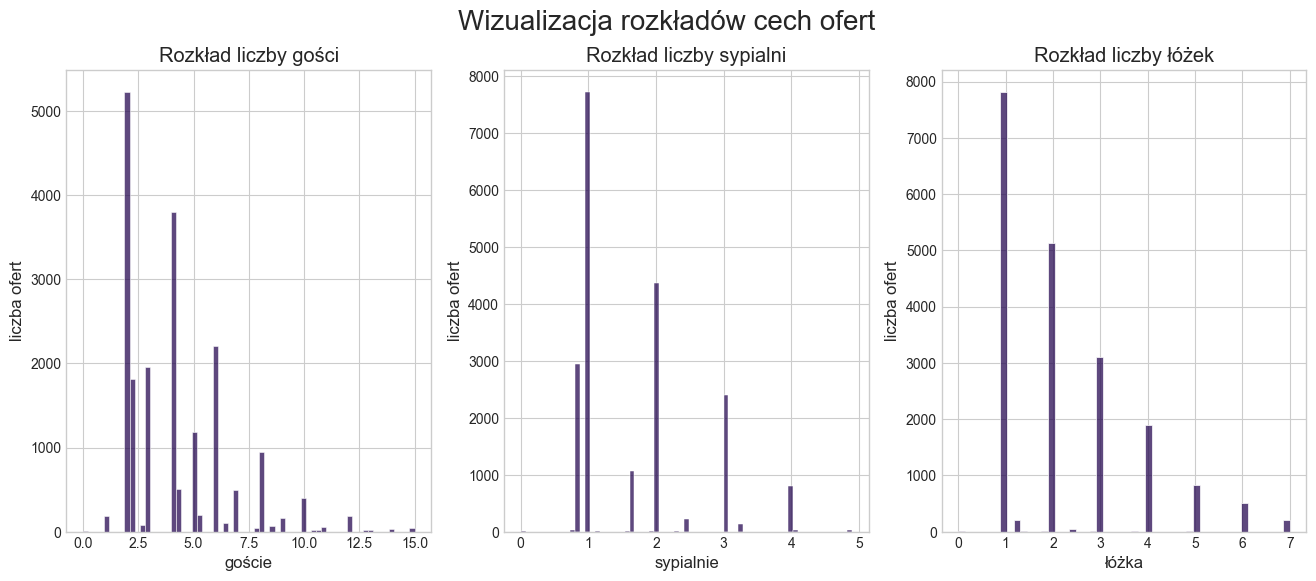

In [1437]:
fig, axes = plt.subplots(1,3, figsize=(16,6))
fig.suptitle('Wizualizacja rozkładów cech ofert', fontsize=20)

sns.histplot(data=listings_df, x='guests',ax=axes[0])
axes[0].set_title('Rozkład liczby gości')
axes[0].set_xlabel('goście')

sns.histplot(data=listings_df, x='bedrooms', ax=axes[1])
axes[1].set_title('Rozkład liczby sypialni')
axes[1].set_xlabel('sypialnie')

sns.histplot(data=listings_df, x='beds', ax=axes[2])
axes[2].set_title('Rozkład liczby łóżek')
axes[2].set_xlabel('łóżka')

for i in range(3):
    axes[i].set_ylabel('liczba ofert')

In [1354]:
listings_df[['guests', 'bedrooms', 'beds']].skew()

guests      1.376590
bedrooms    1.108970
beds        1.205229
dtype: float64

Liczba gości, sypialni i łóżek przypadająca na ofertę airbnb nie są danymi skokowymi, ich dyskretność została naruszona przez uzupełnienie średnią arytmetyczną. Nie mogę przez to narysować KDE - krzywej rozkładu. Widzę, że dane mają silną skośność prawostronną.

### Typy ofert

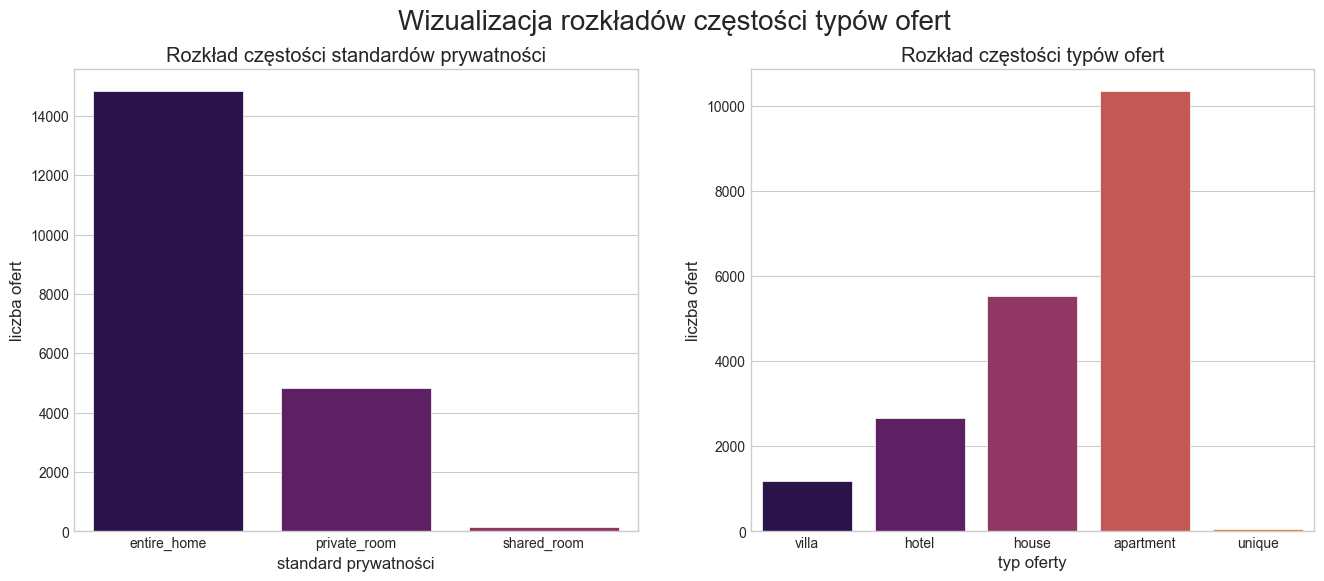

In [1440]:
fig, axes = plt.subplots(1,2, figsize=(16,6))
fig.suptitle('Wizualizacja rozkładów częstości typów ofert', fontsize=20)

sns.countplot(data=listings_df, x='room_type', hue='room_type',ax=axes[0])
axes[0].set_title('Rozkład częstości standardów prywatności')
axes[0].set_xlabel('standard prywatności')

sns.countplot(data=listings_df, x='listing_type',hue='listing_type', ax=axes[1])
axes[1].set_title('Rozkład częstości typów ofert')
axes[1].set_xlabel('typ oferty')

for i in range(2):
    axes[i].set_ylabel('liczba ofert')

- W obu powyższych zbiorach danych dominuje jedna kategoria: dla standardów prywatności jest to entire_home oznaczające akomodacje bez przestrzeni współdzielonej z innymi odwiedzającymi. 
- Dla typów ofert dominuje typ apartment - mieszkanie 

### Cechy opisujące jakość ofert

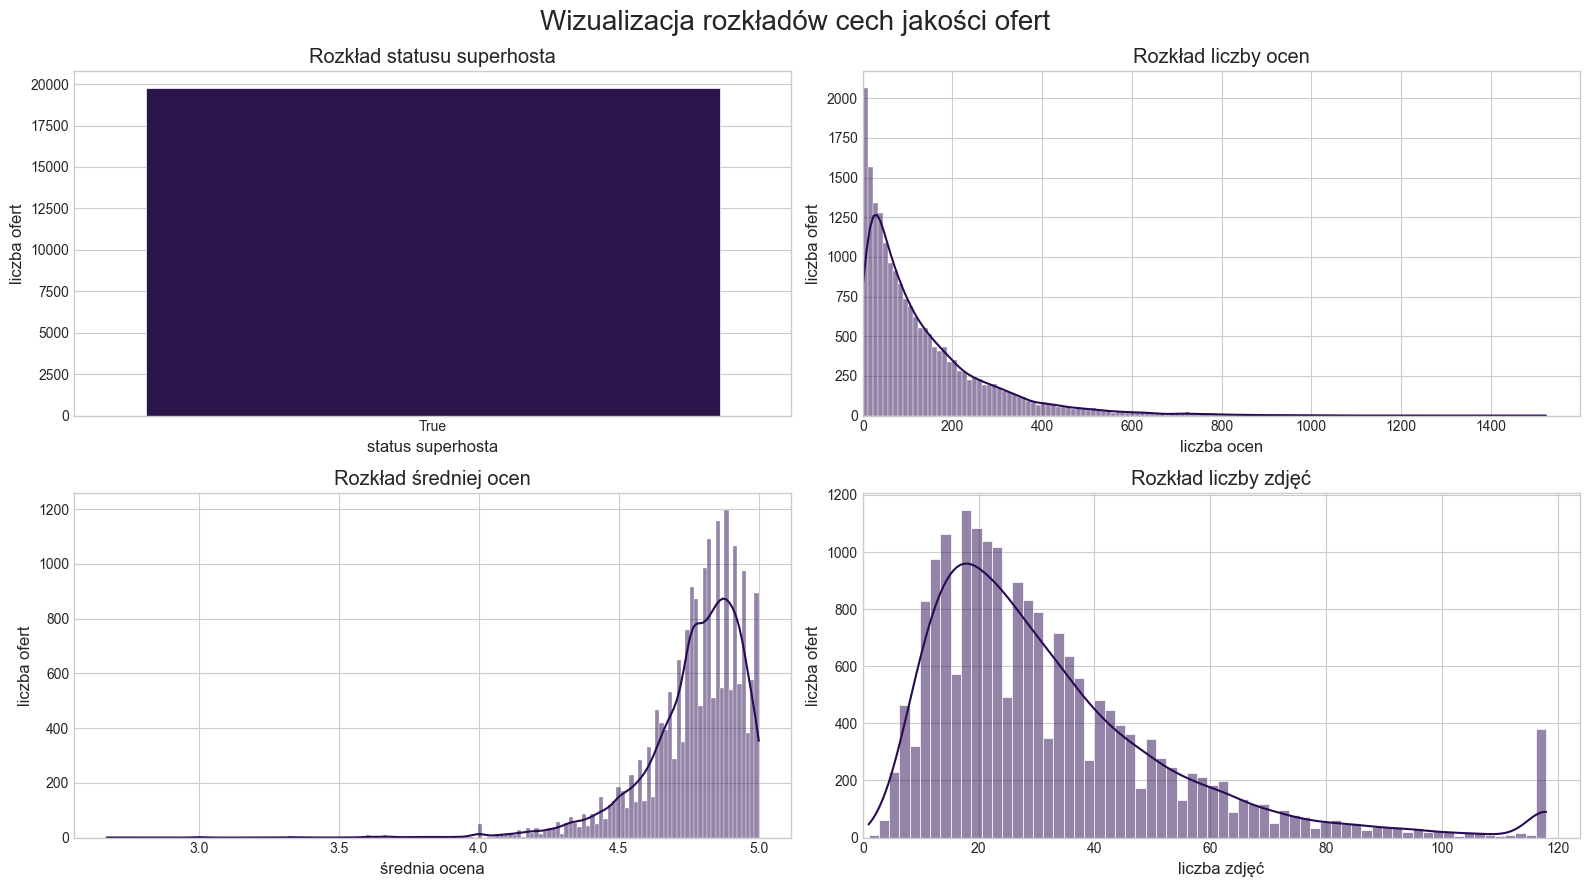

In [1419]:
fig, axes = plt.subplots(2,2, figsize=(16,9))
fig.suptitle('Wizualizacja rozkładów cech jakości ofert', fontsize=20)
axes=axes.flatten()

sns.countplot(data=listings_df, x='superhost',ax=axes[0])
axes[0].set_title('Rozkład statusu superhosta')
axes[0].set_xlabel('status superhosta')

sns.histplot(data=listings_df, x='num_reviews',kde=True, ax=axes[1])
axes[1].set_title('Rozkład liczby ocen')
axes[1].set_xlabel('liczba ocen')
axes[1].set_xlim(0)

sns.histplot(data=listings_df, x='rating_overall',kde=True, ax=axes[2])
axes[2].set_title('Rozkład średniej ocen')
axes[2].set_xlabel('średnia ocena')

sns.histplot(data=listings_df, x='photos_count',kde=True, ax=axes[3])
axes[3].set_title('Rozkład liczby zdjęć')
axes[3].set_xlabel('liczba zdjęć')
axes[3].set_xlim(0)

for i in range(4):
    axes[i].set_ylabel('liczba ofert')
plt.tight_layout()

In [1421]:
listings_df[['num_reviews', 'rating_overall', 'photos_count']].skew()

num_reviews       2.249916
rating_overall   -2.102619
photos_count      1.695861
dtype: float64

Zmienne num_reviews oraz photos_count są określone na wystarczająco dużym przedziale liczb by potraktować je jak zmienne ciągłe, dlatego również dla nich stworzyłam histogramy.

- Wszystkie analizowane oferty zostały wystawione przez osoby o statusie superhosta.
- Liczba ocen ma bardzo silną skośność prawostronna, większość ofert ma poniżej 200 ocen.
- Średnia ocen ma bardzo silną skośność lewostronną, więkość ofert ma oceny powyżej 4.5
- Liczba zdjęć przy ofercie ma silną skośność prawostronną i duża liczę obserwacji 118, przez modyfikację danych na etapie redukcji anomailii

### Położenie geograficzne

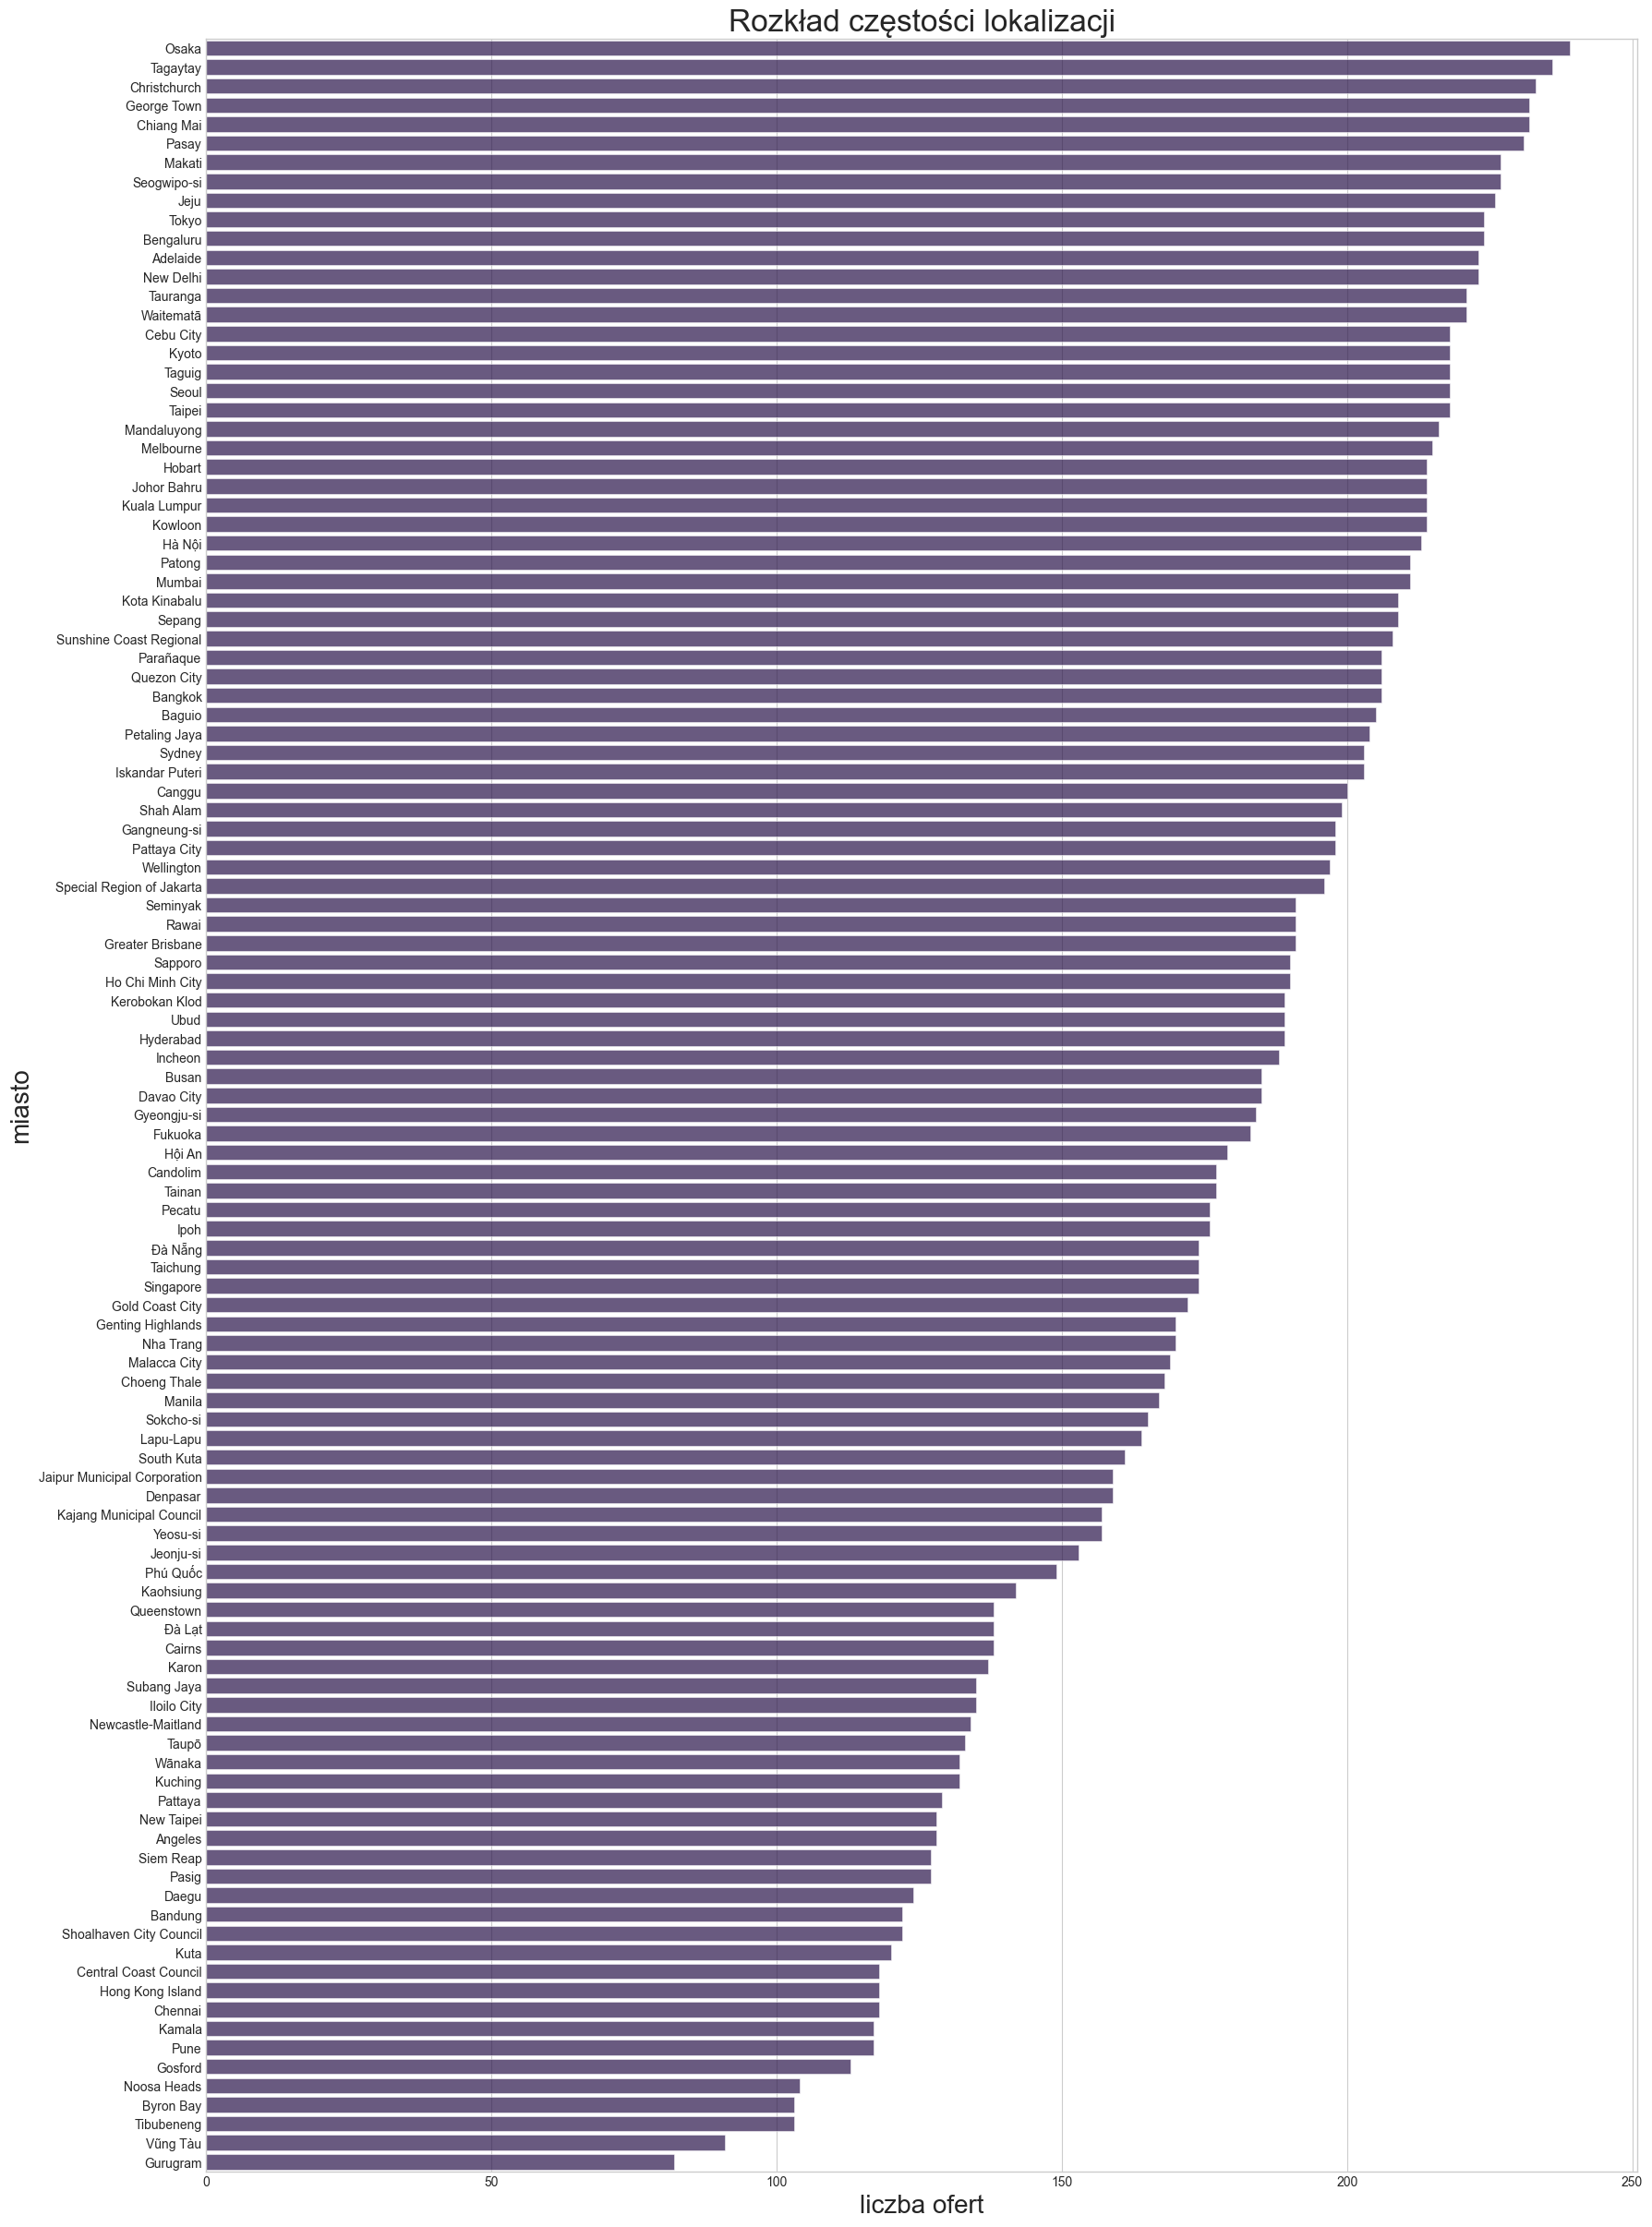

In [1448]:
top_cities=listings_df['city'].value_counts().index
plt.figure(figsize=(20,30))
sns.countplot(data=listings_df,
               y='city',
               order=top_cities, alpha=0.7)
plt.title('Rozkład częstości lokalizacji', size=24)
plt.ylabel('miasto', size=20)
plt.xlabel('liczba ofert', size=20)
plt.show()

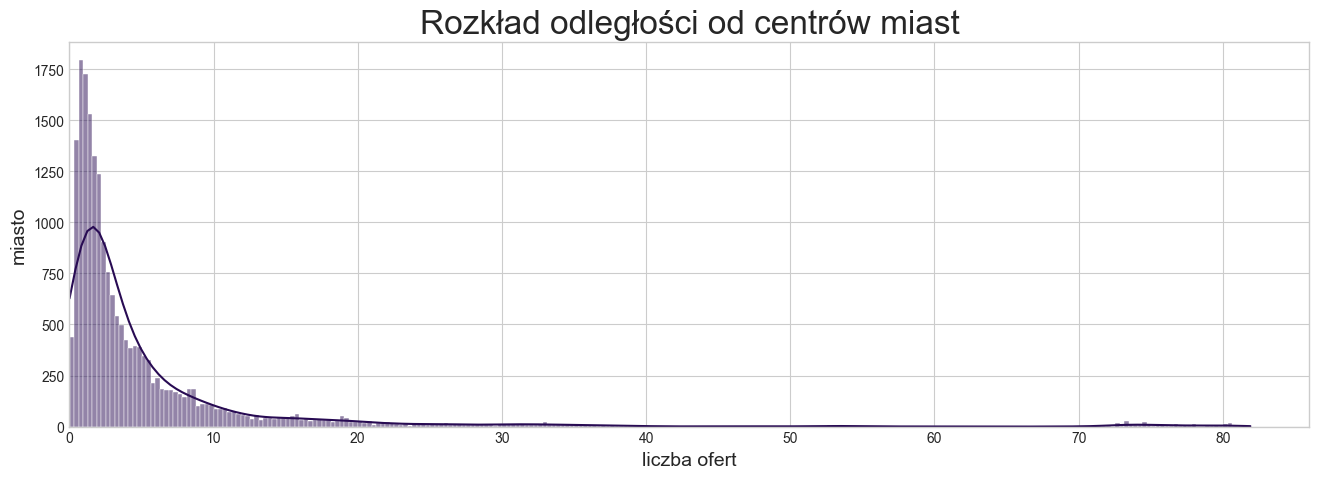

In [1412]:
plt.figure(figsize=(16,5))
sns.histplot(data=listings_df,
               x='center_dist_km',
               kde=True)
plt.title('Rozkład odległości od centrów miast', size=24)
plt.ylabel('miasto', size=14)
plt.xlabel('liczba ofert', size=14)
plt.xlim(0)
plt.show()


In [1422]:
listings_df[['center_dist_km']].skew()

center_dist_km    4.838768
dtype: float64

Każda z lokalizacji ma powyżej 50 oraz mniej niż 250 ofert. Odległość od miast jest bardzo silnie asymetryczna prawostronnie. Istnieją oferty na odludziu tworzące długi ogon.

## Analiza zależności

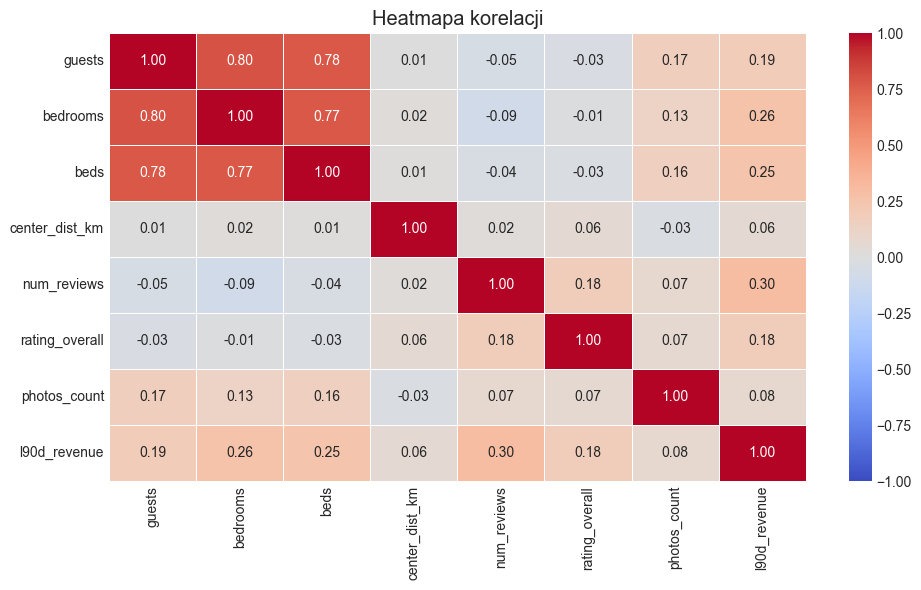

In [1451]:
corr = listings_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white', fmt='.2f')
plt.title('Heatmapa korelacji')
plt.tight_layout()
plt.show()

Najbardziej skorelowane ze sobą są zmienne guests, bedrooms oraz beds. Odznacza się również wpływ liczby opinii, liczby sypialni, łóżek i gości na przychód l90d_revenue. Oferty z większą liczbą opinii mają statystycznie większą średnią ocenę. Obrazuję więc to na wykresach. Sprawdzam również korelacje między typami akomodacji oraz standardem prywatności a przychodem.

Text(0.5, 0, 'Standard prywatności')

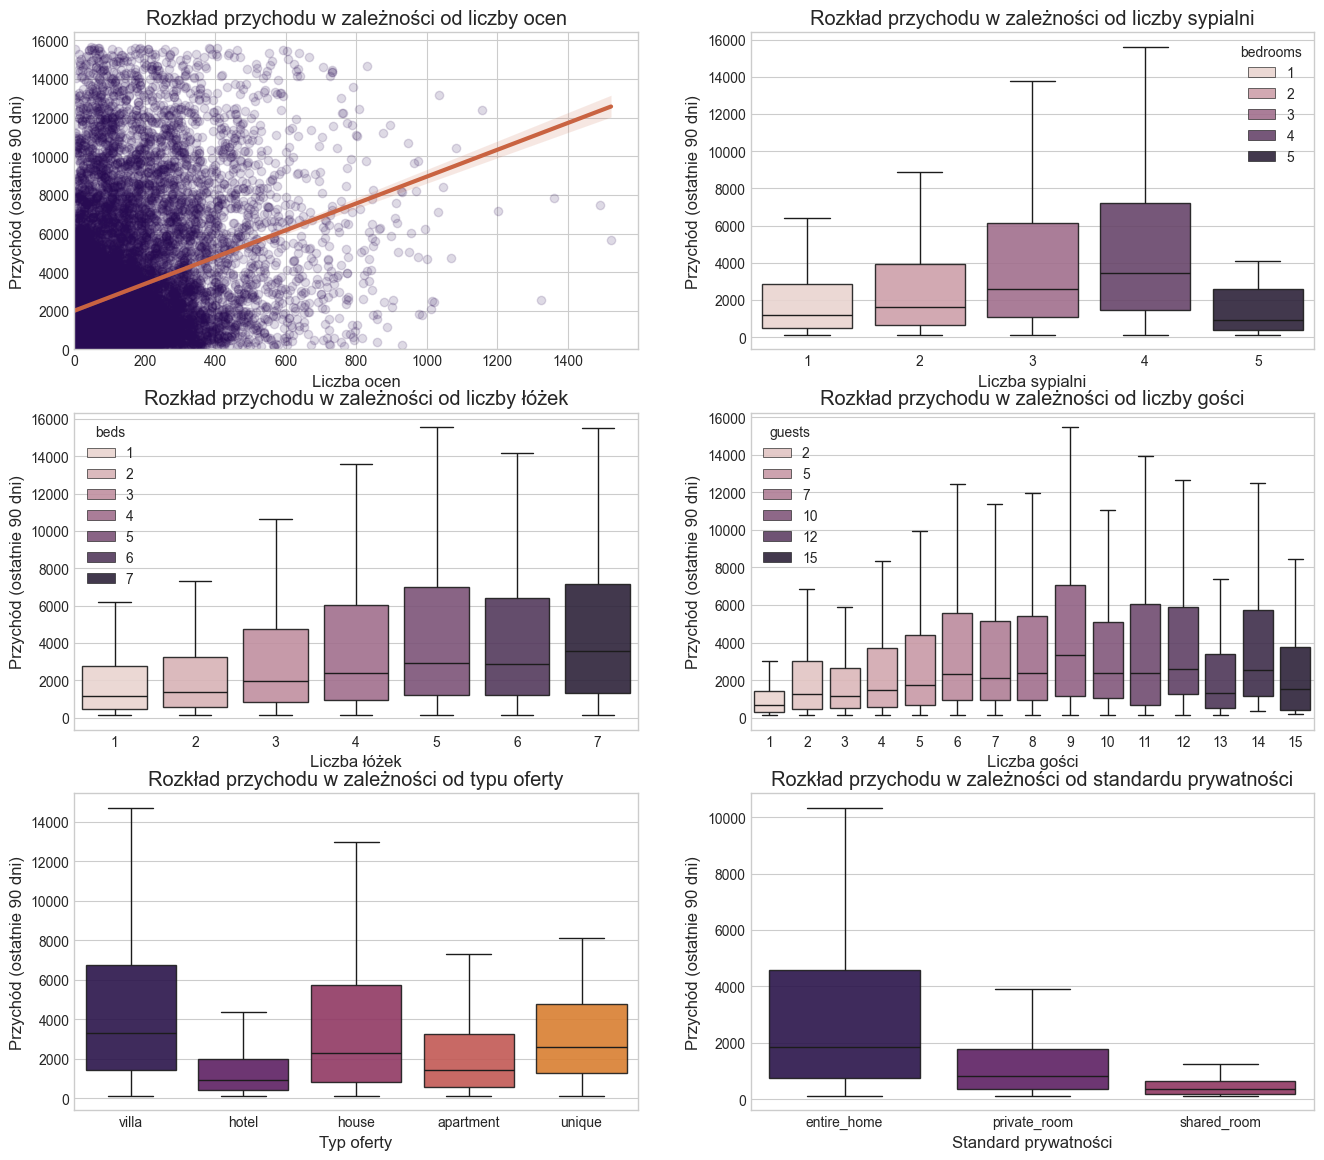

In [1498]:
fig, axes = plt.subplots(3,2, figsize=(16, 14))
axes=axes.flatten()

sns.regplot(
    data=listings_df, 
    x=listings_df['num_reviews'],
    y='l90d_revenue', 
    scatter_kws={'alpha': 0.15},
    line_kws={'color': "#c96341", 'linewidth': 3},
    ax=axes[0]
)
axes[0].set_xlim(0)
axes[0].set_ylim(0)
axes[0].set_title('Rozkład przychodu w zależności od liczby ocen')
axes[0].set_xlabel('Liczba ocen')
axes[0].set_ylabel('Przychód (ostatnie 90 dni)')

cols=['bedrooms', 'beds', 'guests']

for i,col in enumerate(cols):
    sns.boxplot(
    data=listings_df, 
    x=listings_df[col].round().astype(int),
    hue=listings_df[col].round().astype(int),
    y='l90d_revenue', 
    showfliers=False,
    ax=axes[i+1],
    boxprops=dict(alpha=0.9)
    )
    axes[i+1].set_ylabel('Przychód (ostatnie 90 dni)')

cols=['listing_type', 'room_type']

for i, col in enumerate(cols):
    sns.boxplot(
    data=listings_df, 
    x=col,
    hue=col,
    y='l90d_revenue', 
    showfliers=False,
    ax=axes[i+4],
    boxprops=dict(alpha=0.9)
    )
    axes[i+4].set_ylabel('Przychód (ostatnie 90 dni)')


axes[1].set_title('Rozkład przychodu w zależności od liczby sypialni')
axes[1].set_xlabel('Liczba sypialni')

axes[2].set_title('Rozkład przychodu w zależności od liczby łóżek')
axes[2].set_xlabel('Liczba łóżek')

axes[3].set_title('Rozkład przychodu w zależności od liczby gości')
axes[3].set_xlabel('Liczba gości')

axes[4].set_title('Rozkład przychodu w zależności od typu oferty')
axes[4].set_xlabel('Typ oferty')

axes[5].set_title('Rozkład przychodu w zależności od standardu prywatności')
axes[5].set_xlabel('Standard prywatności')


- Widać że mediana przychodów z wynajmu willi jest najwyższa, tu też są największe odchyły: max przychód leży daleko od mediany. 
- Wynajem całych domów przynosi największe przychody zgodnie z ich medianą i umożliwia przy odpowiednich warunkach osiągnięcie zarobków powyżej 10tys. Najmniejszym zróżnicowaniem przychodów odznacza się współdzielony pokój.


## Wizualizacje zaawansowane